In [392]:
#!/usr/bin/env python

#
# Test/demonstrate target and background pixel pairing for purposes of radiance
# ratio determination
#

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import yaml

import pv

#
# Somewhat arbitrarily-chosen plume of interest (plume 'CH4_PlumeComplex-3727',
# scene 'emit20241130t180334'):
#

# data:
cfg_src = './config.yaml'
plume_data_src = './data/previous_manual_annotation_oneback.json'
cfg = yaml.safe_load(open(cfg_src))

# plume instance (also provides access to ch4 matched filter results):
plume = pv.emit_plume.EMITPlume(
    plume_id='CH4_PlumeComplex-3727',
    plume_data=plume_data_src,
    cfg=cfg)

# radiance data:
l1b_radiance = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l1b', type = cfg['emit_l1b_radiance_type'])

# combined mask ('True' for features that should be excluded):
l2a_mask = pv.emit_file.EMITAcquisitionFile(
    root=cfg['emit_acquisition_dataproducts_root'],
    id=plume.fid, level='l2a', type = cfg['emit_l2a_mask_type'])
combined_mask = np.sum(l2a_mask.data[...,:3],axis=-1) > 0                   # clouds, surface water
combined_mask[np.squeeze(plume.ch4_mf.data)<=cfg['NO_DATA_VALUE']] = True   # plus missing ch4_mf data

# "basic" plume mask ("True" for features to include):
plume_mask = np.copy(np.squeeze(plume.mask(random_variation=False)))

# ...and apply combined_mask:
plume_mask = plume_mask & ~combined_mask

#
# plume target pixels ('True' for retained target pixels):
#

# mask out pixels with MF values greater than N-th percentile:
nth_percentile = np.percentile(
    np.squeeze(plume.ch4_mf.data)[plume_mask],
    cfg['CH4_MF_EXCLUDE_PERCENTILE'])
target_pixel_mask = np.logical_and(
    plume_mask, np.squeeze(plume.ch4_mf.data)<=nth_percentile)

# reduce target_pixel_mask to NUM_SEED_PIXELS:
tmp = np.squeeze(plume.ch4_mf.data)[target_pixel_mask]
tmp.sort()
seed_threshold = tmp[-cfg['NUM_SEED_PIXELS']]
target_pixel_mask = np.logical_and(
    target_pixel_mask,
    (np.squeeze(plume.ch4_mf.data)*target_pixel_mask)>=seed_threshold)

# "blur" pixel mask to form "region" of target pixels:
dilated_target_pixel_mask = gaussian_filter(
    target_pixel_mask.astype(float),
    sigma=cfg['GAUSSIAN_FILTER_SIGMA']) > \
        cfg['GAUSSIAN_FILTER_RESULTS_THRESHOLD']

# and reapply combined mask in case Gaussian filtering has reintroduced pixels
# that should be excluded:
dilated_target_pixel_mask = dilated_target_pixel_mask & ~combined_mask

# option to retain only those target pixels corresponding to positive ch4
# matched filter values:
if cfg['POSITIVE_TARGET_PIXELS_ONLY']:
    dilated_target_pixel_mask = np.logical_and(
        dilated_target_pixel_mask, np.squeeze(plume.ch4_mf.data)>0.)

#
# background pixels ('True' for candidate background pixels):
#

bpe = cfg['BACKGROUND_PAIRING_EXTENTS_IN_PIXELS']       # notational
mf_delta = cfg['BACKGROUND_PAIRING_CH4_MF_THRESHOLD']   # convenience

background_pixel_mask = np.zeros(plume_mask.shape,dtype=bool)
num_lines,num_samples = background_pixel_mask.shape

# consider background region based on target pixel extents...:
line_indices,sample_indices = np.nonzero(dilated_target_pixel_mask)
background_pixel_mask[
    max(0,min(line_indices)-bpe) : min(num_lines,max(line_indices)+bpe),
    max(0,min(sample_indices)-bpe) : min(num_samples,max(sample_indices)+bpe)] = True

# as is the case with target pixels, make sure water and missing features are excluded:
background_pixel_mask = background_pixel_mask & ~combined_mask

# remove target pixels from consideration:
background_pixel_mask = background_pixel_mask & ~dilated_target_pixel_mask

# filter background pixels according to MF value range:
#background_pixel_mask = background_pixel_mask & ~combined_mask
background_pixel_mask = np.logical_and(
    background_pixel_mask,
    np.logical_and(
        np.squeeze(plume.ch4_mf.data) > -mf_delta,
        np.squeeze(plume.ch4_mf.data) <  mf_delta))

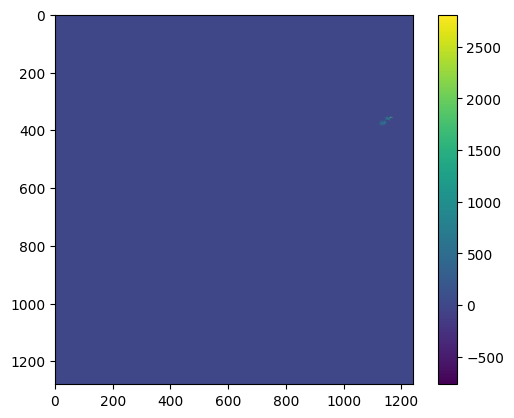

In [393]:
fig, axs = plt.subplots()
img = axs.imshow(np.squeeze(plume.ch4_mf.data)*plume_mask)
_ = fig.colorbar(img)

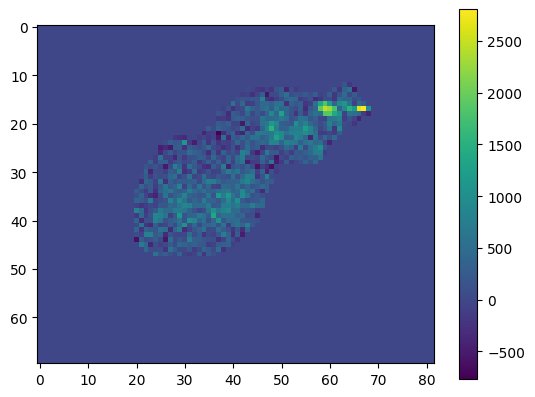

In [394]:
line_slice = slice(340,410)
sample_slice = slice(1100,-60)
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*plume_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

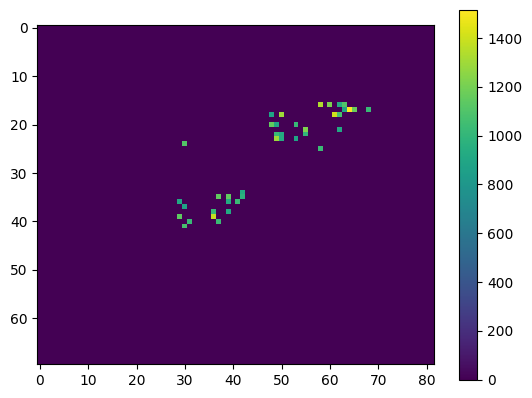

In [395]:
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*target_pixel_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

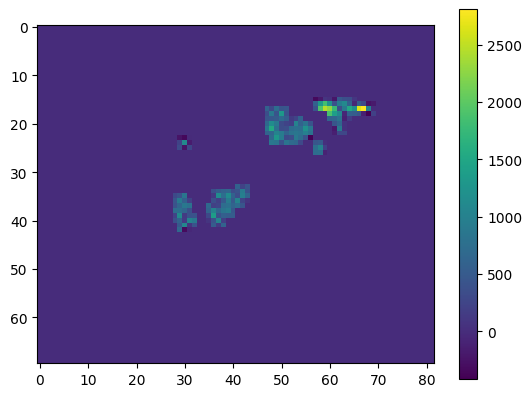

In [396]:
fig, axs = plt.subplots()
img = axs.imshow((np.squeeze(plume.ch4_mf.data)*dilated_target_pixel_mask)[line_slice,sample_slice])
_ = fig.colorbar(img)

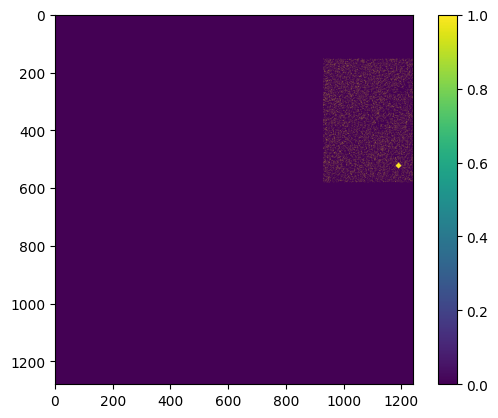

In [397]:
fig, axs = plt.subplots()
img = axs.imshow(background_pixel_mask)
#img = axs.imshow(background_pixel_mask[line_slice,sample_slice])
_ = fig.colorbar(img)

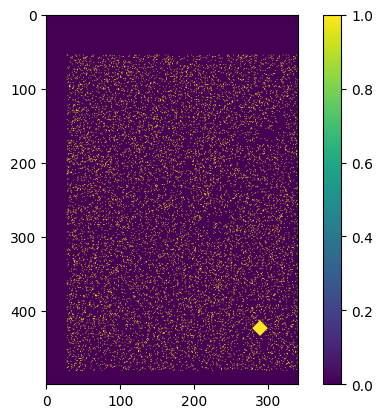

In [398]:
fig, axs = plt.subplots()
img = axs.imshow(background_pixel_mask[100:600,900:-1])
#img = axs.imshow(background_pixel_mask[line_slice,sample_slice])
_ = fig.colorbar(img)

In [399]:
print(f'dilated_target_pixel_mask nonzeros: {np.count_nonzero(dilated_target_pixel_mask)}')
print(f'background_pixel_mask nonzeros: {np.count_nonzero(background_pixel_mask)}')

dilated_target_pixel_mask nonzeros: 227
background_pixel_mask nonzeros: 11243


In [400]:
print(l1b_radiance.data.shape)
print(l1b_radiance.data[dilated_target_pixel_mask].shape)

(1280, 1242, 285)
(227, 285)


In [401]:
dilated_target_pixel_mask_indices = np.where(dilated_target_pixel_mask)
background_pixel_mask_indices = np.where(background_pixel_mask)

In [402]:
wl = np.array(l1b_radiance.hdr['wavelength'],dtype=float)
ch4_rngs = np.array(cfg['ch4_absorption_ranges'])
ch4_wl_indices = np.where(((wl >= ch4_rngs[0,0]) & (wl <= ch4_rngs[0,1])) | ((wl >= ch4_rngs[1,0]) & (wl <= ch4_rngs[1,1])))[0]
non_ch4_wl_indices = np.where(~((wl >= ch4_rngs[0,0]) & (wl <= ch4_rngs[0,1])) | ((wl >= ch4_rngs[1,0]) & (wl <= ch4_rngs[1,1])))[0]
target_non_ch4_spectra = l1b_radiance.data[dilated_target_pixel_mask][:,non_ch4_wl_indices]
background_non_ch4_spectra = l1b_radiance.data[background_pixel_mask][:,non_ch4_wl_indices]

In [403]:
# L1-normalized Euclidian distance spectral similarity matrix (target pixel rows x background pixel columns):
similarity_matrix = cdist( target_non_ch4_spectra, background_non_ch4_spectra, 'euclidean')

In [404]:
similarity_matrix.shape

(227, 11243)

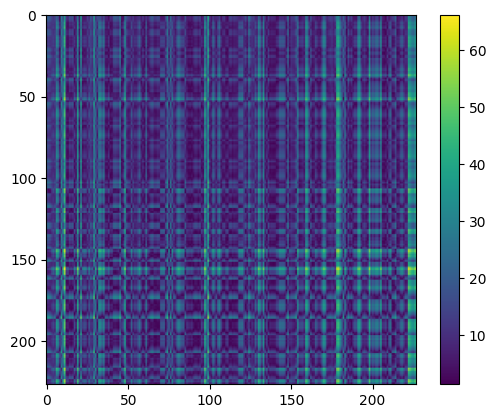

In [405]:
# plot a square segment of the similarity matrix (given the shape, view of entire matrix is not very illustrative):
fig, axs = plt.subplots()
img = axs.imshow(similarity_matrix[:227,-227:])
_ = fig.colorbar(img)

In [406]:
# use optimal assignment to determine non-repeated index pairs (for each target pixel, corresponding "best fit" background pixel,
# no background pixel used more than once):
target_indices, background_indices = linear_sum_assignment(similarity_matrix)

In [407]:
# gather indices, metrics in DataFrame for subsequent operations, analysis:
similarity_results_df = pd.DataFrame(columns=[
    'similarity_matrix_target_index',
    'similarity_matrix_background_index',
    'similarity_matrix_coefficient',
    'target_indices',
    'background_indices',
    'target_mf',
    'mean_target_radiance',
    'mean_background_radiance'])
for tgt_idx,bg_idx in zip(target_indices, background_indices):
    similarity_results_df.loc[tgt_idx] = [
        tgt_idx,
        bg_idx,
        similarity_matrix[tgt_idx,bg_idx],
        (dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx]),
        (background_pixel_mask_indices[0][bg_idx],background_pixel_mask_indices[1][bg_idx]),
        np.squeeze(plume.ch4_mf.data[(dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx])]),
        np.mean(l1b_radiance.data[(dilated_target_pixel_mask_indices[0][tgt_idx],dilated_target_pixel_mask_indices[1][tgt_idx]),:]),
        np.mean(l1b_radiance.data[(background_pixel_mask_indices[0][tgt_idx],background_pixel_mask_indices[1][tgt_idx]),:]),
    ]

In [408]:
similarity_results_df

,similarity_matrix_target_index,similarity_matrix_background_index,similarity_matrix_coefficient,target_indices,background_indices,target_mf,mean_target_radiance,mean_background_radiance
0,0,4927,0.673250,"(355, 1157)","(343, 1156)",-331.0264,2.468878,2.562405
1,1,5232,0.577683,"(355, 1158)","(354, 1159)",-190.46614,2.469854,2.564194
2,2,1405,0.484692,"(355, 1159)","(206, 1219)",85.5982,2.470955,2.551566
3,3,8299,0.610725,"(355, 1160)","(474, 1104)",51.533077,2.472339,2.541377
4,4,3873,0.722853,"(355, 1161)","(299, 1193)",-224.64949,2.480322,2.541100
...,...,...,...,...,...,...,...,...
222,222,5693,0.611524,"(381, 1137)","(373, 1100)",140.38458,2.398529,2.467106
223,223,674,0.517989,"(381, 1138)","(179, 1163)",614.6413,2.403958,2.482454
224,224,3095,1.062610,"(382, 1129)","(271, 1218)",679.99506,2.396967,2.468343
225,225,5089,1.189572,"(382, 1130)","(349, 1126)",-314.3956,2.395144,2.461488
